# 6. Exploratory deep learning on raw waveforms

Goal:
- test whether a small 1D CNN on raw waveforms can capture signal related to high_glucose
- keep the experiment protocol-specific and anatomically targeted
- avoid leakage by splitting at patient level

In [298]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

## 6.1. Configuration

In [299]:
DL_TARGET_COL = "high_glucose"
DL_TARGET_LENGTH = 2000

# Start with the most plausible protocol/site/frequency combinations
# suggested by the previous exploratory analyses.
DL_EXPERIMENTS = [
    {"protocol_version": "old", "site_code": "A", "frequency_hz": 800},
    {"protocol_version": "old", "site_code": "A", "frequency_hz": 1000},
    {"protocol_version": "new", "site_code": "B", "frequency_hz": 800},
    {"protocol_version": "new", "site_code": "B", "frequency_hz": 1000},
]

tf.keras.utils.set_random_seed(42)

## 6.2. Small helpers

In [300]:
def _fix_length(signal_array, target_length=2000):
    """
    Truncate or zero-pad one waveform to a fixed length.
    """
    arr = np.asarray(signal_array, dtype=np.float32)

    if arr.size >= target_length:
        return arr[:target_length]

    out = np.zeros(target_length, dtype=np.float32)
    out[:arr.size] = arr
    return out

In [301]:
def _build_dl_waveform_table(
    df,
    protocol_version,
    site_code,
    frequency_hz,
    target_col="high_glucose",
    target_length=2000,
):
    """
    Build one row per analysis unit:
    patient x protocol x timepoint x site

    Repeated acquisitions inside the same unit are aggregated by
    taking the median waveform across retained acquisitions.
    """
    unit_dict = {}

    subset_df = df.loc[
        (df["protocol_version"] == protocol_version) &
        (df["site_code"] == site_code) &
        (df[target_col].notna())
    ].copy()

    for row in subset_df.itertuples(index=False):
        if not isinstance(row.freq_to_array, dict):
            continue
        if frequency_hz not in row.freq_to_array:
            continue

        waveform = _fix_length(
            row.freq_to_array[frequency_hz],
            target_length=target_length,
        )

        unit_key = (
            row.global_patient_id,
            row.hospital_patient_id,
            row.protocol_version,
            row.timepoint,
            row.site_code,
        )

        if unit_key not in unit_dict:
            unit_dict[unit_key] = {
                "global_patient_id": row.global_patient_id,
                "hospital_patient_id": row.hospital_patient_id,
                "protocol_version": row.protocol_version,
                "timepoint": row.timepoint,
                "site_code": row.site_code,
                "target": int(row.high_glucose),
                "waveforms": [],
            }

        unit_dict[unit_key]["waveforms"].append(waveform)

    rows = []

    for _, item in unit_dict.items():
        waveform_stack = np.vstack(item["waveforms"])
        median_waveform = np.median(waveform_stack, axis=0).astype(np.float32)

        rows.append({
            "global_patient_id": item["global_patient_id"],
            "hospital_patient_id": item["hospital_patient_id"],
            "protocol_version": item["protocol_version"],
            "timepoint": item["timepoint"],
            "site_code": item["site_code"],
            "target": item["target"],
            "n_acquisitions_aggregated": int(waveform_stack.shape[0]),
            "waveform": median_waveform,
        })

    return pd.DataFrame(rows)

In [302]:
def _find_group_splits(df, target_col="target", group_col="global_patient_id"):
    """
    Try several random states until a valid patient-level
    train/validation/test split is found.

    The split is accepted only if train, validation, and test
    all contain both classes.
    """
    for seed in range(42, 80):
        gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
        train_val_idx, test_idx = next(
            gss_test.split(df, groups=df[group_col])
        )

        train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)

        gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
        train_idx, val_idx = next(
            gss_val.split(train_val_df, groups=train_val_df[group_col])
        )

        train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
        val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

        ok_train = train_df[target_col].nunique() == 2
        ok_val = val_df[target_col].nunique() == 2
        ok_test = test_df[target_col].nunique() == 2

        if ok_train and ok_val and ok_test:
            return train_df, val_df, test_df

    return None, None, None

In [303]:
def _build_small_cnn(input_length):
    """
    Small 1D CNN for exploratory modelling.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.Conv1D(16, kernel_size=9, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),

        tf.keras.layers.Conv1D(32, kernel_size=7, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),

        tf.keras.layers.Conv1D(64, kernel_size=5, padding="same", activation="relu"),
        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
    )

    return model

In [304]:
def _run_dl_experiment(dl_df, label):
    """
    Train and evaluate one exploratory raw-signal deep-learning model.
    """
    if dl_df.empty:
        return None, None, None

    class_counts = dl_df["target"].value_counts(dropna=False)
    if len(class_counts) < 2 or class_counts.min() < 8 or len(dl_df) < 50:
        return None, None, None

    train_df, val_df, test_df = _find_group_splits(dl_df)

    if train_df is None:
        return None, None, None

    X_train = np.stack(train_df["waveform"].to_numpy())
    X_val = np.stack(val_df["waveform"].to_numpy())
    X_test = np.stack(test_df["waveform"].to_numpy())

    y_train = train_df["target"].astype(int).to_numpy()
    y_val = val_df["target"].astype(int).to_numpy()
    y_test = test_df["target"].astype(int).to_numpy()

    # Global scaling based only on the training split
    train_mean = float(X_train.mean())
    train_std = float(X_train.std()) if float(X_train.std()) > 0 else 1.0

    X_train = (X_train - train_mean) / train_std
    X_val = (X_val - train_mean) / train_std
    X_test = (X_test - train_mean) / train_std

    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    model = _build_small_cnn(X_train.shape[1])

    class_weight_values = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train,
    )
    class_weight = {
        int(cls): float(weight)
        for cls, weight in zip(np.unique(y_train), class_weight_values)
    }

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=8,
            restore_best_weights=True,
        )
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=16,
        verbose=0,
        class_weight=class_weight,
        callbacks=callbacks,
    )

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    result = {
        "experiment": label,
        "protocol_version": dl_df["protocol_version"].iloc[0],
        "site_code": dl_df["site_code"].iloc[0],
        "n_units_total": int(len(dl_df)),
        "n_positive_total": int(dl_df["target"].sum()),
        "n_train": int(len(train_df)),
        "n_val": int(len(val_df)),
        "n_test": int(len(test_df)),
        "test_roc_auc": float(roc_auc_score(y_test, y_prob)),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    }

    history_df = pd.DataFrame(history.history)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)

    return result, history_df, (train_df, val_df, test_df)


## 6.3. Run the exploratory deep-learning experiments

In [305]:
dl_result_rows = []
dl_history_dict = {}

for exp in DL_EXPERIMENTS:
    label = (
        f'{exp["protocol_version"]} | '
        f'{exp["site_code"]} | '
        f'{exp["frequency_hz"]}Hz'
    )

    dl_df = _build_dl_waveform_table(
        df=stat_base_df,
        protocol_version=exp["protocol_version"],
        site_code=exp["site_code"],
        frequency_hz=exp["frequency_hz"],
        target_col=DL_TARGET_COL,
        target_length=DL_TARGET_LENGTH,
    )

    print("\n" + "=" * 60)
    print(f"Deep-learning experiment: {label}")
    print("=" * 60)
    print(f"Units available: {len(dl_df)}")
    if not dl_df.empty:
        print(f"Positives: {int(dl_df['target'].sum())}")

    result, history_df, split_tuple = _run_dl_experiment(dl_df, label)

    if result is not None:
        dl_result_rows.append(result)
        dl_history_dict[label] = history_df

dl_results_df = pd.DataFrame(dl_result_rows)


Deep-learning experiment: old | A | 800Hz
Units available: 157
Positives: 27

Deep-learning experiment: old | A | 1000Hz
Units available: 157
Positives: 27

Deep-learning experiment: new | B | 800Hz
Units available: 86
Positives: 9

Deep-learning experiment: new | B | 1000Hz
Units available: 86
Positives: 9


In [306]:
if not dl_results_df.empty:
    dl_results_df = dl_results_df.sort_values(
        ["test_roc_auc", "test_balanced_accuracy"],
        ascending=[False, False],
    ).reset_index(drop=True)

print("\nExploratory deep-learning results")
display(dl_results_df)


Exploratory deep-learning results


,experiment,protocol_version,site_code,n_units_total,n_positive_total,n_train,n_val,n_test,test_roc_auc,test_balanced_accuracy
0,old | A | 800Hz,old,A,157,27,93,32,32,0.681481,0.633333
1,old | A | 1000Hz,old,A,157,27,93,32,32,0.603704,0.566667
2,new | B | 1000Hz,new,B,86,9,51,17,18,0.593750,0.500000
3,new | B | 800Hz,new,B,86,9,51,17,18,0.562500,0.531250


## 6.4. Compare with the best classical models for high_glucose

In [307]:
dl_comparison_df = pd.DataFrame()

if not dl_results_df.empty:
    dl_compare = dl_results_df[
        [
            "protocol_version",
            "experiment",
            "test_roc_auc",
            "test_balanced_accuracy",
        ]
    ].copy()
    dl_compare["comparison_type"] = "deep_learning"

    classical_compare = pd.DataFrame()

    if "model_comparison_df" in globals():
        classical_compare = model_comparison_df.loc[
            model_comparison_df["protocol_version"].isin(dl_compare["protocol_version"].unique())
        ].copy()

        classical_compare = classical_compare.rename(
            columns={
                "feature_block": "experiment",
                "mean_roc_auc": "test_roc_auc",
                "mean_balanced_accuracy": "test_balanced_accuracy",
            }
        )

    if not classical_compare.empty:
        classical_compare = classical_compare[
            [
                "protocol_version",
                "experiment",
                "test_roc_auc",
                "test_balanced_accuracy",
                "comparison_type",
            ]
        ]

    dl_comparison_df = pd.concat(
        [classical_compare, dl_compare],
        ignore_index=True,
    )

    print("\nComparison: classical baselines vs exploratory deep learning")
    display(dl_comparison_df.sort_values(["protocol_version", "comparison_type", "test_roc_auc"], ascending=[True, True, False]))



Comparison: classical baselines vs exploratory deep learning


,protocol_version,experiment,test_roc_auc,test_balanced_accuracy,comparison_type
0,new,physics,0.653919,0.545409,baseline
7,new,new | B | 1000Hz,0.593750,0.500000,deep_learning
8,new,new | B | 800Hz,0.562500,0.531250,deep_learning
2,new,targeted_site_frequency (BP),0.599785,0.596935,targeted
1,old,signal,0.598878,0.579647,baseline
5,old,old | A | 800Hz,0.681481,0.633333,deep_learning
6,old,old | A | 1000Hz,0.603704,0.566667,deep_learning
3,old,targeted_site_frequency (A),0.582308,0.577949,targeted
4,old,targeted_site_frequency (P),0.545128,0.589744,targeted


## 6.5. Compact plots

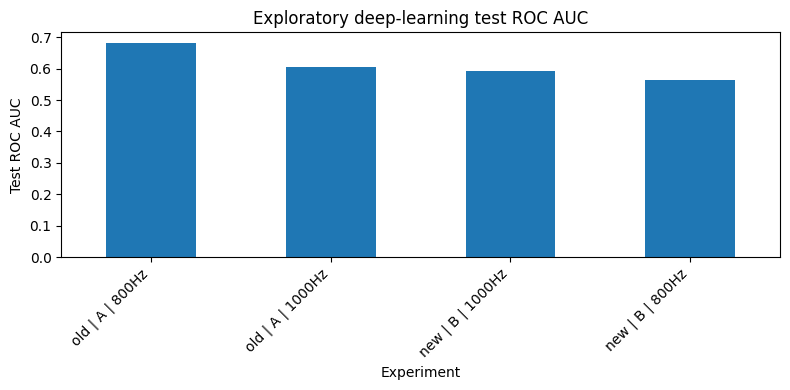

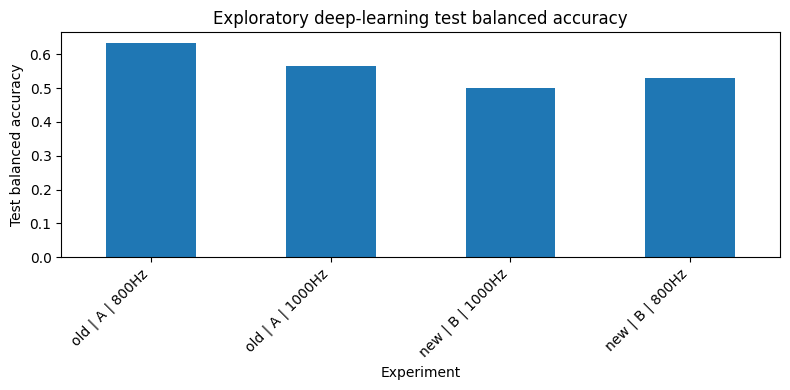

In [308]:
if not dl_results_df.empty:
    # Test ROC AUC
    ax = dl_results_df.set_index("experiment")["test_roc_auc"].plot(
        kind="bar",
        figsize=(8, 4),
    )
    ax.set_title("Exploratory deep-learning test ROC AUC")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Test ROC AUC")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Test balanced accuracy
    ax = dl_results_df.set_index("experiment")["test_balanced_accuracy"].plot(
        kind="bar",
        figsize=(8, 4),
    )
    ax.set_title("Exploratory deep-learning test balanced accuracy")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Test balanced accuracy")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


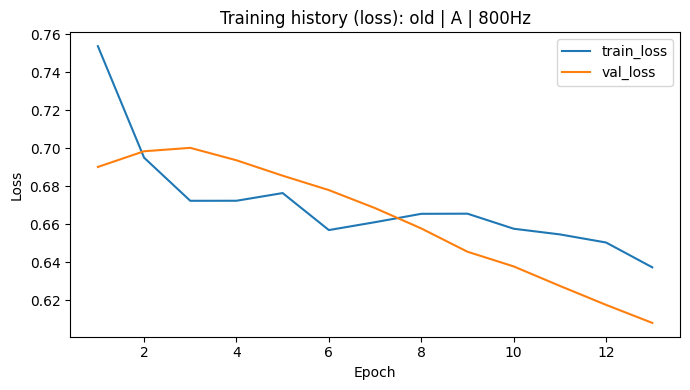

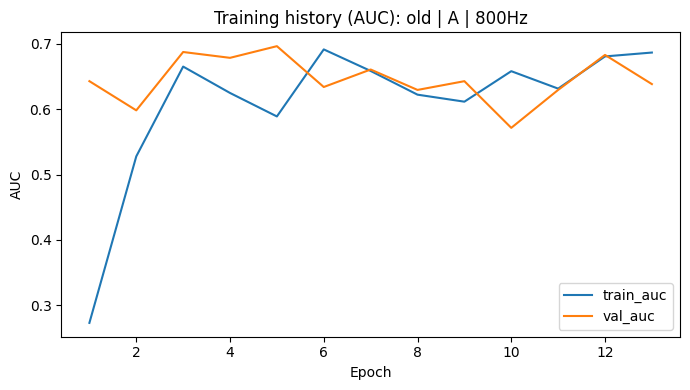

In [309]:
# show training curves for the best experiment
if not dl_results_df.empty:
    best_label = dl_results_df.iloc[0]["experiment"]
    history_df = dl_history_dict[best_label]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history_df["epoch"], history_df["loss"], label="train_loss")
    ax.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    ax.set_title(f"Training history (loss): {best_label}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

    if "auc" in history_df.columns and "val_auc" in history_df.columns:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(history_df["epoch"], history_df["auc"], label="train_auc")
        ax.plot(history_df["epoch"], history_df["val_auc"], label="val_auc")
        ax.set_title(f"Training history (AUC): {best_label}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("AUC")
        ax.legend()
        plt.tight_layout()
        plt.show()

# 7. High-capacity raw-signal deep learning experiment

Focused experiment: old | A | 800Hz
This experiment uses RAW SIGNAL explicitly:
 - one input = one aggregated raw waveform at 800 Hz
 - repeated acquisitions are aggregated at unit level using the previous helper
 - splitting is done by patient to avoid leakage

In [310]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

## 7.1. Configuration

In [311]:
DL_STRONG_PROTOCOL = "old"
DL_STRONG_SITE = "A"
DL_STRONG_FREQUENCY = 800
DL_STRONG_TARGET = "high_glucose"

DL_RANDOM_SEEDS = [42, 52, 62, 72, 82]
DL_MAX_EPOCHS = 120
DL_BATCH_SIZE = 16

## 7.2. Build the raw-waveform table

In [312]:
dl_strong_df = _build_dl_waveform_table(
    df=stat_base_df,
    protocol_version=DL_STRONG_PROTOCOL,
    site_code=DL_STRONG_SITE,
    frequency_hz=DL_STRONG_FREQUENCY,
    target_col=DL_STRONG_TARGET,
    target_length=DL_TARGET_LENGTH,
)

In [313]:
print("\nHigh-capacity raw-signal experiment")
print(f"Protocol = {DL_STRONG_PROTOCOL}")
print(f"Site = {DL_STRONG_SITE}")
print(f"Frequency = {DL_STRONG_FREQUENCY} Hz")
print(f"Units available = {len(dl_strong_df)}")

if not dl_strong_df.empty:
    print(f"Positive units = {int(dl_strong_df['target'].sum())}")

display(dl_strong_df.head())


High-capacity raw-signal experiment
Protocol = old
Site = A
Frequency = 800 Hz
Units available = 157
Positive units = 27


,global_patient_id,hospital_patient_id,protocol_version,timepoint,site_code,target,n_acquisitions_aggregated,waveform
0,1,540,old,POST,A,0,3,"[-0.016842978, -0.01766243, -0.018652538, -0.0..."
1,2,533,old,POST,A,0,3,"[0.020864287, 0.020560514, 0.020414073, 0.0198..."
2,3,534,old,POST,A,0,3,"[0.020884886, 0.018760335, 0.018924862, 0.0209..."
3,4,535,old,POST,A,0,3,"[0.008897244, 0.00851217, 0.008457706, 0.00784..."
4,5,538,old,POST,A,0,3,"[0.018779026, 0.019069916, 0.018407056, 0.0185..."


## 7.3. Patient-level split

In [314]:
train_df, val_df, test_df = _find_group_splits(
    dl_strong_df,
    target_col="target",
    group_col="global_patient_id",
)

if train_df is None:
    raise ValueError("Could not find a valid patient-level split with both classes in all partitions.")

print("\nSplit sizes")
print(f"Train = {len(train_df)}")
print(f"Validation = {len(val_df)}")
print(f"Test = {len(test_df)}")


Split sizes
Train = 93
Validation = 32
Test = 32


## 7.4. Prepare RAW SIGNAL tensors

In [315]:
X_train = np.stack(train_df["waveform"].to_numpy()).astype(np.float32)
X_val = np.stack(val_df["waveform"].to_numpy()).astype(np.float32)
X_test = np.stack(test_df["waveform"].to_numpy()).astype(np.float32)

y_train = train_df["target"].astype(int).to_numpy()
y_val = val_df["target"].astype(int).to_numpy()
y_test = test_df["target"].astype(int).to_numpy()

### 7.4.1. Standardise using ONLY the training raw waveforms

In [316]:
train_mean = float(X_train.mean())
train_std = float(X_train.std()) if float(X_train.std()) > 0 else 1.0

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

### 7.4.2. Add channel dimension for Conv1D

In [317]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("\nRAW SIGNAL tensor shapes")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)



RAW SIGNAL tensor shapes
X_train: (93, 2000, 1)
X_val: (32, 2000, 1)
X_test: (32, 2000, 1)


## 7.5. Stronger 1D CNN on RAW SIGNAL

In [318]:
def _residual_block_1d(x, filters, kernel_size, dropout_rate=0.15):
    """
    Residual 1D block for raw waveform modelling.
    """
    shortcut = x

    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
    )(x)
    y = tf.keras.layers.BatchNormalization()(y)
    y = tf.keras.layers.Activation("relu")(y)

    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
    )(y)
    y = tf.keras.layers.BatchNormalization()(y)

    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same",
            use_bias=False,
        )(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    y = tf.keras.layers.Add()([shortcut, y])
    y = tf.keras.layers.Activation("relu")(y)
    y = tf.keras.layers.SpatialDropout1D(dropout_rate)(y)

    return y

In [319]:
def _build_stronger_raw_cnn(input_length):
    """
    Stronger residual CNN for raw waveform classification.
    """
    inputs = tf.keras.layers.Input(shape=(input_length, 1))

    x = tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=15,
        padding="same",
        use_bias=False,
    )(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

    x = _residual_block_1d(x, filters=32, kernel_size=11, dropout_rate=0.10)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

    x = _residual_block_1d(x, filters=64, kernel_size=9, dropout_rate=0.15)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

    x = _residual_block_1d(x, filters=128, kernel_size=7, dropout_rate=0.20)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

    x = _residual_block_1d(x, filters=128, kernel_size=5, dropout_rate=0.20)

    avg_pool = tf.keras.layers.GlobalAveragePooling1D()(x)
    max_pool = tf.keras.layers.GlobalMaxPooling1D()(x)
    x = tf.keras.layers.Concatenate()([avg_pool, max_pool])

    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
    )

    return model

## 7.6. Class weights

In [320]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)

class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(y_train), class_weight_values)
}

print("\nClass weights")
print(class_weight)


Class weights
{0: 0.62, 1: 2.5833333333333335}


## 7.7. Train several RAW SIGNAL models with different seeds

In [321]:
dl_strong_rows = []
dl_strong_histories = {}
dl_test_prob_dict = {}

for seed in DL_RANDOM_SEEDS:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = _build_stronger_raw_cnn(X_train.shape[1])

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=15,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=0,
        ),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=DL_MAX_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        verbose=0,
        class_weight=class_weight,
        callbacks=callbacks,
    )

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_test, y_prob)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    dl_strong_rows.append({
        "seed": seed,
        "n_epochs_trained": int(len(history.history["loss"])),
        "test_roc_auc": float(roc_auc),
        "test_balanced_accuracy": float(bal_acc),
    })

    history_df = pd.DataFrame(history.history)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)
    dl_strong_histories[seed] = history_df
    dl_test_prob_dict[seed] = y_prob

dl_strong_results_df = pd.DataFrame(dl_strong_rows).sort_values(
    "test_roc_auc", ascending=False
).reset_index(drop=True)

print("\nSeed-level results for the stronger RAW SIGNAL CNN")
display(dl_strong_results_df)


Seed-level results for the stronger RAW SIGNAL CNN


,seed,n_epochs_trained,test_roc_auc,test_balanced_accuracy
0,62,16,0.696296,0.492593
1,72,18,0.651852,0.492593
2,42,16,0.629630,0.500000
3,82,34,0.629630,0.685185
4,52,44,0.585185,0.562963


## 7.8. Ensemble prediction across seeds

In [322]:
ensemble_prob = np.mean(
    np.column_stack([dl_test_prob_dict[seed] for seed in DL_RANDOM_SEEDS]),
    axis=1,
)
ensemble_pred = (ensemble_prob >= 0.5).astype(int)

dl_strong_ensemble_df = pd.DataFrame([{
    "experiment": f"{DL_STRONG_PROTOCOL} | {DL_STRONG_SITE} | {DL_STRONG_FREQUENCY}Hz | stronger_raw_cnn_ensemble",
    "n_models_ensembled": int(len(DL_RANDOM_SEEDS)),
    "test_roc_auc": float(roc_auc_score(y_test, ensemble_prob)),
    "test_balanced_accuracy": float(balanced_accuracy_score(y_test, ensemble_pred)),
    "n_test": int(len(y_test)),
    "n_test_positive": int(y_test.sum()),
}])

print("\nEnsemble result")
display(dl_strong_ensemble_df)


Ensemble result


,experiment,n_models_ensembled,test_roc_auc,test_balanced_accuracy,n_test,n_test_positive
0,old | A | 800Hz | stronger_raw_cnn_ensemble,5,0.681481,0.492593,32,5


## 7.9. Compare against previous best classical and previous DL

In [323]:
comparison_rows = []

if "model_comparison_df" in globals():
    old_compare_df = model_comparison_df.loc[
        model_comparison_df["protocol_version"] == DL_STRONG_PROTOCOL
    ].copy()

    if not old_compare_df.empty:
        old_compare_df = old_compare_df.rename(
            columns={
                "feature_block": "experiment",
                "mean_roc_auc": "test_roc_auc",
                "mean_balanced_accuracy": "test_balanced_accuracy",
            }
        )
        old_compare_df = old_compare_df[
            ["protocol_version", "experiment", "test_roc_auc", "test_balanced_accuracy", "comparison_type"]
        ]
        comparison_rows.append(old_compare_df)

if "dl_results_df" in globals():
    previous_dl_compare_df = dl_results_df.loc[
        (dl_results_df["protocol_version"] == DL_STRONG_PROTOCOL) &
        (dl_results_df["site_code"] == DL_STRONG_SITE)
    ].copy()

    if not previous_dl_compare_df.empty:
        previous_dl_compare_df["comparison_type"] = "previous_deep_learning"
        previous_dl_compare_df = previous_dl_compare_df[
            ["protocol_version", "experiment", "test_roc_auc", "test_balanced_accuracy", "comparison_type"]
        ]
        comparison_rows.append(previous_dl_compare_df)

strong_ensemble_compare_df = dl_strong_ensemble_df.copy()
strong_ensemble_compare_df["protocol_version"] = DL_STRONG_PROTOCOL
strong_ensemble_compare_df["comparison_type"] = "stronger_deep_learning"
strong_ensemble_compare_df = strong_ensemble_compare_df[
    ["protocol_version", "experiment", "test_roc_auc", "test_balanced_accuracy", "comparison_type"]
]
comparison_rows.append(strong_ensemble_compare_df)

dl_strong_comparison_df = pd.concat(comparison_rows, ignore_index=True)

print("\nComparison with previous old-protocol models")
display(
    dl_strong_comparison_df.sort_values(
        ["comparison_type", "test_roc_auc"],
        ascending=[True, False],
    ).reset_index(drop=True)
)


Comparison with previous old-protocol models


,protocol_version,experiment,test_roc_auc,test_balanced_accuracy,comparison_type
0,old,signal,0.598878,0.579647,baseline
1,old,old | A | 800Hz,0.681481,0.633333,previous_deep_learning
2,old,old | A | 1000Hz,0.603704,0.566667,previous_deep_learning
3,old,old | A | 800Hz | stronger_raw_cnn_ensemble,0.681481,0.492593,stronger_deep_learning
4,old,targeted_site_frequency (A),0.582308,0.577949,targeted
5,old,targeted_site_frequency (P),0.545128,0.589744,targeted


## 7.10. Compact plots

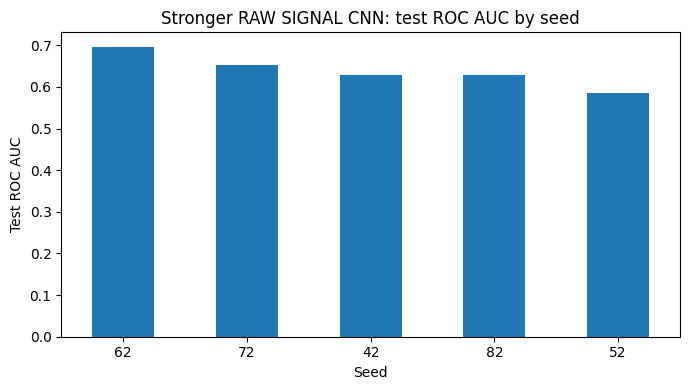

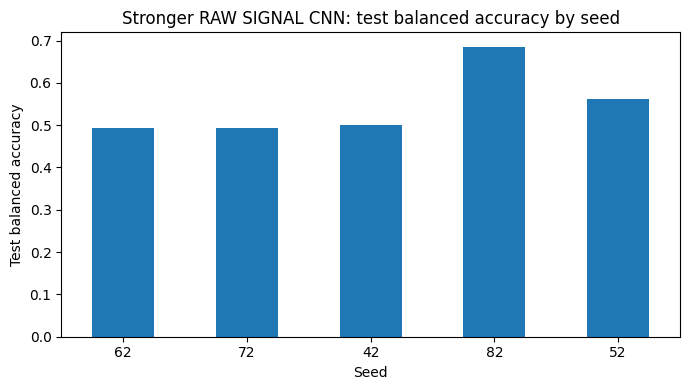

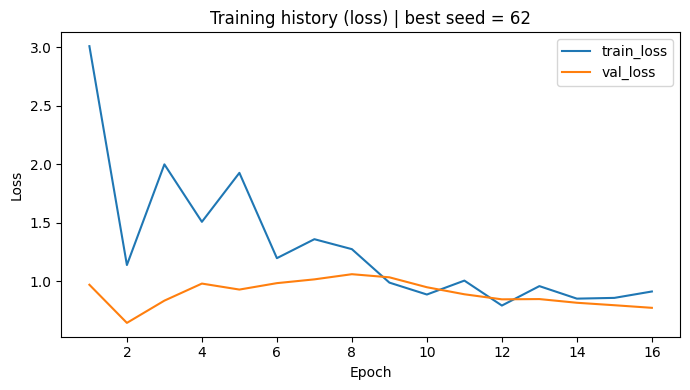

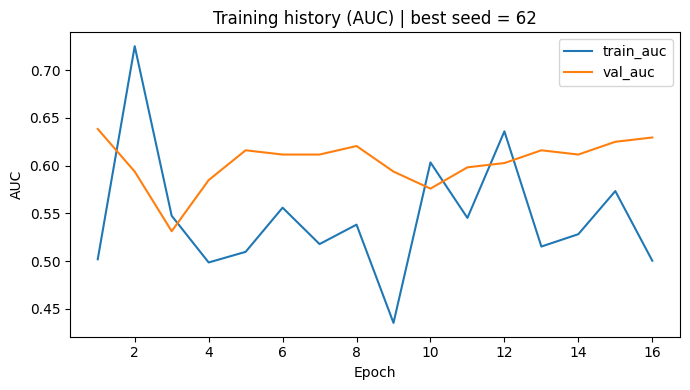

In [324]:
ax = dl_strong_results_df.set_index("seed")["test_roc_auc"].plot(
    kind="bar",
    figsize=(7, 4),
)
ax.set_title("Stronger RAW SIGNAL CNN: test ROC AUC by seed")
ax.set_xlabel("Seed")
ax.set_ylabel("Test ROC AUC")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ax = dl_strong_results_df.set_index("seed")["test_balanced_accuracy"].plot(
    kind="bar",
    figsize=(7, 4),
)
ax.set_title("Stronger RAW SIGNAL CNN: test balanced accuracy by seed")
ax.set_xlabel("Seed")
ax.set_ylabel("Test balanced accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_seed = int(dl_strong_results_df.iloc[0]["seed"])
best_history_df = dl_strong_histories[best_seed]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(best_history_df["epoch"], best_history_df["loss"], label="train_loss")
ax.plot(best_history_df["epoch"], best_history_df["val_loss"], label="val_loss")
ax.set_title(f"Training history (loss) | best seed = {best_seed}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

if "auc" in best_history_df.columns and "val_auc" in best_history_df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(best_history_df["epoch"], best_history_df["auc"], label="train_auc")
    ax.plot(best_history_df["epoch"], best_history_df["val_auc"], label="val_auc")
    ax.set_title(f"Training history (AUC) | best seed = {best_seed}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("AUC")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 8. Exploratory test: multi-frequency RAW SIGNAL deep learning

 Goal:
 - combine the two best frequencies per protocol as two channels
 - keep the experiment simple and patient-level
 - compare against the previous single-frequency DL results

## 8.1. Configuration

In [325]:
DL_MULTI_EXPERIMENTS = [
    {
        "protocol_version": "old",
        "site_code": "A",
        "frequencies_hz": [800, 1000],
        "label": "old | A | 800+1000Hz",
    },
    {
        "protocol_version": "new",
        "site_code": "B",
        "frequencies_hz": [800, 1000],
        "label": "new | B | 800+1000Hz",
    },
]

DL_MULTI_TARGET = "high_glucose"
DL_MULTI_SEEDS = [42, 52, 62]

## 8.2. Helper: build a multi-frequency raw waveform table

In [326]:
def _build_multifreq_dl_table(
    df,
    protocol_version,
    site_code,
    frequencies_hz,
    target_col="high_glucose",
    target_length=2000,
):
    """
    Build one row per analytical unit with one RAW waveform channel per frequency.
    Only units that contain all requested frequencies are retained.
    """
    freq_tables = []

    for frequency_hz in frequencies_hz:
        freq_df = _build_dl_waveform_table(
            df=df,
            protocol_version=protocol_version,
            site_code=site_code,
            frequency_hz=frequency_hz,
            target_col=target_col,
            target_length=target_length,
        ).copy()

        if freq_df.empty:
            return pd.DataFrame()

        freq_df = freq_df.rename(columns={"waveform": f"waveform_{int(frequency_hz)}Hz"})
        freq_tables.append(freq_df)

    merge_keys = [
        "global_patient_id",
        "hospital_patient_id",
        "protocol_version",
        "timepoint",
        "site_code",
        "target",
        "n_acquisitions_aggregated",
    ]

    out = freq_tables[0].copy()
    for next_df in freq_tables[1:]:
        keep_cols = merge_keys[:-1] + [c for c in next_df.columns if c.startswith("waveform_")]
        out = out.merge(
            next_df[keep_cols],
            on=merge_keys[:-1],
            how="inner",
        )

    return out

## 8.3. Small multichannel CNN

In [327]:
def _build_small_multichannel_cnn(input_length, n_channels):
    """
    Compact 1D CNN for multichannel raw waveform input.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, n_channels)),
        tf.keras.layers.Conv1D(16, kernel_size=9, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),

        tf.keras.layers.Conv1D(32, kernel_size=7, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),

        tf.keras.layers.Conv1D(64, kernel_size=5, padding="same", activation="relu"),
        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
    )
    return model

## 8.4. Run the final multi-frequency experiments

In [328]:
dl_multi_rows = []

for exp in DL_MULTI_EXPERIMENTS:
    print("\n" + "=" * 60)
    print(f"Final multi-frequency DL experiment: {exp['label']}")
    print("=" * 60)

    dl_multi_df = _build_multifreq_dl_table(
        df=stat_base_df,
        protocol_version=exp["protocol_version"],
        site_code=exp["site_code"],
        frequencies_hz=exp["frequencies_hz"],
        target_col=DL_MULTI_TARGET,
        target_length=DL_TARGET_LENGTH,
    )

    print(f"Units available: {len(dl_multi_df)}")
    if not dl_multi_df.empty:
        print(f"Positive units: {int(dl_multi_df['target'].sum())}")

    if dl_multi_df.empty:
        continue

    class_counts = dl_multi_df["target"].value_counts(dropna=False)
    if len(class_counts) < 2 or class_counts.min() < 8 or len(dl_multi_df) < 50:
        print("Not enough data for a stable experiment.")
        continue

    train_df, val_df, test_df = _find_group_splits(
        dl_multi_df,
        target_col="target",
        group_col="global_patient_id",
    )

    if train_df is None:
        print("Could not find a valid patient-level split.")
        continue

    waveform_cols = [f"waveform_{int(freq)}Hz" for freq in exp["frequencies_hz"]]

    def _stack_multichannel(df_part):
        channel_list = [
            np.stack(df_part[col].to_numpy()).astype(np.float32)
            for col in waveform_cols
        ]
        X = np.stack(channel_list, axis=-1)
        return X

    X_train = _stack_multichannel(train_df)
    X_val = _stack_multichannel(val_df)
    X_test = _stack_multichannel(test_df)

    y_train = train_df["target"].astype(int).to_numpy()
    y_val = val_df["target"].astype(int).to_numpy()
    y_test = test_df["target"].astype(int).to_numpy()

    # Standardise from training data only
    train_mean = float(X_train.mean())
    train_std = float(X_train.std()) if float(X_train.std()) > 0 else 1.0

    X_train = (X_train - train_mean) / train_std
    X_val = (X_val - train_mean) / train_std
    X_test = (X_test - train_mean) / train_std

    class_weight_values = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train,
    )
    class_weight = {
        int(cls): float(weight)
        for cls, weight in zip(np.unique(y_train), class_weight_values)
    }

    seed_rows = []
    seed_prob_dict = {}

    for seed in DL_MULTI_SEEDS:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seed)

        model = _build_small_multichannel_cnn(
            input_length=X_train.shape[1],
            n_channels=X_train.shape[2],
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=8,
                restore_best_weights=True,
            )
        ]

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=16,
            verbose=0,
            class_weight=class_weight,
            callbacks=callbacks,
        )

        y_prob = model(X_test, training=False).numpy().ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        seed_rows.append({
            "seed": seed,
            "test_roc_auc": float(roc_auc_score(y_test, y_prob)),
            "test_balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
            "n_epochs_trained": int(len(history.history["loss"])),
        })

        seed_prob_dict[seed] = y_prob

    seed_df = pd.DataFrame(seed_rows).sort_values(
        "test_roc_auc", ascending=False
    ).reset_index(drop=True)

    ensemble_prob = np.mean(
        np.column_stack([seed_prob_dict[seed] for seed in DL_MULTI_SEEDS]),
        axis=1,
    )
    ensemble_pred = (ensemble_prob >= 0.5).astype(int)

    ensemble_row = {
        "experiment": exp["label"],
        "protocol_version": exp["protocol_version"],
        "site_code": exp["site_code"],
        "frequencies_hz": ", ".join(str(x) for x in exp["frequencies_hz"]),
        "n_units_total": int(len(dl_multi_df)),
        "n_positive_total": int(dl_multi_df["target"].sum()),
        "n_test": int(len(y_test)),
        "n_test_positive": int(y_test.sum()),
        "ensemble_test_roc_auc": float(roc_auc_score(y_test, ensemble_prob)),
        "ensemble_test_balanced_accuracy": float(balanced_accuracy_score(y_test, ensemble_pred)),
        "best_seed_roc_auc": float(seed_df["test_roc_auc"].max()),
        "best_seed_balanced_accuracy": float(seed_df["test_balanced_accuracy"].max()),
    }

    print("\nSeed-level results")
    display(seed_df)

    dl_multi_rows.append(ensemble_row)

dl_multi_results_df = pd.DataFrame(dl_multi_rows)

print("\nFinal multi-frequency DL results")
display(dl_multi_results_df)


Final multi-frequency DL experiment: old | A | 800+1000Hz
Units available: 157
Positive units: 27

Seed-level results


,seed,test_roc_auc,test_balanced_accuracy,n_epochs_trained
0,62,0.681481,0.492593,11
1,42,0.674074,0.492593,11
2,52,0.659259,0.492593,12



Final multi-frequency DL experiment: new | B | 800+1000Hz
Units available: 86
Positive units: 9

Seed-level results


,seed,test_roc_auc,test_balanced_accuracy,n_epochs_trained
0,42,0.5625,0.5,9
1,52,0.5625,0.5,9
2,62,0.5625,0.5,9



Final multi-frequency DL results


,experiment,protocol_version,site_code,frequencies_hz,n_units_total,n_positive_total,n_test,n_test_positive,ensemble_test_roc_auc,ensemble_test_balanced_accuracy,best_seed_roc_auc,best_seed_balanced_accuracy
0,old | A | 800+1000Hz,old,A,"800, 1000",157,27,32,5,0.666667,0.492593,0.681481,0.492593
1,new | B | 800+1000Hz,new,B,"800, 1000",86,9,18,2,0.562500,0.500000,0.562500,0.500000


## 8.5. Compare with previous single-frequency DL and classical models

In [329]:
multi_compare_parts = []

if "dl_results_df" in globals():
    prev_single_dl_df = dl_results_df.copy()
    prev_single_dl_df["comparison_type"] = "single_frequency_dl"
    prev_single_dl_df = prev_single_dl_df.rename(columns={
        "test_roc_auc": "roc_auc",
        "test_balanced_accuracy": "balanced_accuracy",
    })
    prev_single_dl_df = prev_single_dl_df[
        ["protocol_version", "experiment", "roc_auc", "balanced_accuracy", "comparison_type"]
    ]
    multi_compare_parts.append(prev_single_dl_df)

if "model_comparison_df" in globals():
    prev_classical_df = model_comparison_df.copy()
    prev_classical_df = prev_classical_df.rename(columns={
        "feature_block": "experiment",
        "mean_roc_auc": "roc_auc",
        "mean_balanced_accuracy": "balanced_accuracy",
    })
    prev_classical_df = prev_classical_df[
        ["protocol_version", "experiment", "roc_auc", "balanced_accuracy", "comparison_type"]
    ]
    multi_compare_parts.append(prev_classical_df)

if not dl_multi_results_df.empty:
    multi_dl_compare_df = dl_multi_results_df.rename(columns={
        "ensemble_test_roc_auc": "roc_auc",
        "ensemble_test_balanced_accuracy": "balanced_accuracy",
    }).copy()
    multi_dl_compare_df["comparison_type"] = "multi_frequency_dl"
    multi_dl_compare_df = multi_dl_compare_df[
        ["protocol_version", "experiment", "roc_auc", "balanced_accuracy", "comparison_type"]
    ]
    multi_compare_parts.append(multi_dl_compare_df)

if len(multi_compare_parts) > 0:
    final_multi_comparison_df = pd.concat(multi_compare_parts, ignore_index=True)

    print("\nComparison: classical vs single-frequency DL vs multi-frequency DL")
    display(
        final_multi_comparison_df.sort_values(
            ["protocol_version", "comparison_type", "roc_auc"],
            ascending=[True, True, False],
        ).reset_index(drop=True)
    )


Comparison: classical vs single-frequency DL vs multi-frequency DL


,protocol_version,experiment,roc_auc,balanced_accuracy,comparison_type
0,new,physics,0.653919,0.545409,baseline
1,new,new | B | 800+1000Hz,0.562500,0.500000,multi_frequency_dl
2,new,new | B | 1000Hz,0.593750,0.500000,single_frequency_dl
3,new,new | B | 800Hz,0.562500,0.531250,single_frequency_dl
4,new,targeted_site_frequency (BP),0.599785,0.596935,targeted
5,old,signal,0.598878,0.579647,baseline
6,old,old | A | 800+1000Hz,0.666667,0.492593,multi_frequency_dl
7,old,old | A | 800Hz,0.681481,0.633333,single_frequency_dl
8,old,old | A | 1000Hz,0.603704,0.566667,single_frequency_dl
9,old,targeted_site_frequency (A),0.582308,0.577949,targeted


# 9. Exploratory TCN on RAW SIGNAL

TCN on RAW SIGNAL:
 1) old only
 2) pooled old + new

Experiments:
 - old | A | 800Hz | TCN
 - old+new | best sites | 800Hz | TCN

In [330]:
TCN_TARGET_COL = "high_glucose"
TCN_FREQUENCY_HZ = 800
TCN_SEEDS = [42, 52, 62]
TCN_MAX_EPOCHS = 60
TCN_BATCH_SIZE = 16


##  9.1. Build the two datasets

In [331]:
# A) old only: use the best old candidate
tcn_old_df = _build_dl_waveform_table(
    df=stat_base_df,
    protocol_version="old",
    site_code="A",
    frequency_hz=TCN_FREQUENCY_HZ,
    target_col=TCN_TARGET_COL,
    target_length=DL_TARGET_LENGTH,
).copy()

In [332]:
# B) pooled old + new: use the best site found within each protocol
tcn_old_part_df = _build_dl_waveform_table(
    df=stat_base_df,
    protocol_version="old",
    site_code="A",
    frequency_hz=TCN_FREQUENCY_HZ,
    target_col=TCN_TARGET_COL,
    target_length=DL_TARGET_LENGTH,
).copy()

tcn_new_part_df = _build_dl_waveform_table(
    df=stat_base_df,
    protocol_version="new",
    site_code="B",
    frequency_hz=TCN_FREQUENCY_HZ,
    target_col=TCN_TARGET_COL,
    target_length=DL_TARGET_LENGTH,
).copy()



In [333]:
# Add a protocol indicator for the pooled experiment old = 0, new = 1
if not tcn_old_part_df.empty:
    tcn_old_part_df["protocol_binary"] = 0

if not tcn_new_part_df.empty:
    tcn_new_part_df["protocol_binary"] = 1

tcn_pooled_df = pd.concat(
    [tcn_old_part_df, tcn_new_part_df],
    ignore_index=True,
)

In [334]:
# For consistency, old-only also gets a protocol channel = 0
if not tcn_old_df.empty:
    tcn_old_df["protocol_binary"] = 0

print("\nTCN dataset: old only")
print(f"Units available: {len(tcn_old_df)}")
if not tcn_old_df.empty:
    print(f"Positive units: {int(tcn_old_df['target'].sum())}")

print("\nTCN dataset: pooled old + new")
print(f"Units available: {len(tcn_pooled_df)}")
if not tcn_pooled_df.empty:
    print(f"Positive units: {int(tcn_pooled_df['target'].sum())}")


TCN dataset: old only
Units available: 157
Positive units: 27

TCN dataset: pooled old + new
Units available: 243
Positive units: 36


## 9.2. TCN model

In [335]:
def _tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.10):
    shortcut = x

    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal",
        use_bias=False,
    )(x)
    y = tf.keras.layers.BatchNormalization()(y)
    y = tf.keras.layers.Activation("relu")(y)
    y = tf.keras.layers.SpatialDropout1D(dropout_rate)(y)

    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal",
        use_bias=False,
    )(y)
    y = tf.keras.layers.BatchNormalization()(y)

    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same",
            use_bias=False,
        )(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    y = tf.keras.layers.Add()([shortcut, y])
    y = tf.keras.layers.Activation("relu")(y)

    return y

In [336]:
def _build_tcn_model(input_length, n_channels):
    inputs = tf.keras.layers.Input(shape=(input_length, n_channels))

    x = _tcn_residual_block(inputs, filters=32, kernel_size=7, dilation_rate=1, dropout_rate=0.10)
    x = _tcn_residual_block(x, filters=32, kernel_size=7, dilation_rate=2, dropout_rate=0.10)
    x = _tcn_residual_block(x, filters=64, kernel_size=5, dilation_rate=4, dropout_rate=0.15)
    x = _tcn_residual_block(x, filters=64, kernel_size=5, dilation_rate=8, dropout_rate=0.15)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
    )
    return model


## 9.3. Prepare tensors

In [337]:
def _prepare_tcn_tensors(df):
    """
    Build raw-signal tensors and append a constant protocol channel.
    """
    train_df, val_df, test_df = _find_group_splits(
        df,
        target_col="target",
        group_col="global_patient_id",
    )

    if train_df is None:
        return None, None, None, None, None, None

    def _stack_with_protocol_channel(df_part):
        X_signal = np.stack(df_part["waveform"].to_numpy()).astype(np.float32)
        X_signal = X_signal[..., np.newaxis]

        protocol_channel = df_part["protocol_binary"].astype(float).to_numpy()
        protocol_channel = protocol_channel[:, np.newaxis, np.newaxis]
        protocol_channel = np.repeat(protocol_channel, X_signal.shape[1], axis=1)

        X = np.concatenate([X_signal, protocol_channel], axis=-1)
        return X

    X_train = _stack_with_protocol_channel(train_df)
    X_val = _stack_with_protocol_channel(val_df)
    X_test = _stack_with_protocol_channel(test_df)

    y_train = train_df["target"].astype(int).to_numpy()
    y_val = val_df["target"].astype(int).to_numpy()
    y_test = test_df["target"].astype(int).to_numpy()

    # Standardise only the raw-signal channel from training data
    train_mean = float(X_train[:, :, 0].mean())
    train_std = float(X_train[:, :, 0].std()) if float(X_train[:, :, 0].std()) > 0 else 1.0

    X_train[:, :, 0] = (X_train[:, :, 0] - train_mean) / train_std
    X_val[:, :, 0] = (X_val[:, :, 0] - train_mean) / train_std
    X_test[:, :, 0] = (X_test[:, :, 0] - train_mean) / train_std

    return X_train, X_val, X_test, y_train, y_val, y_test


## 9.4. Runner

In [338]:
def _run_tcn_experiment(df, label):
    if df.empty:
        return None, None

    class_counts = df["target"].value_counts(dropna=False)
    if len(class_counts) < 2 or class_counts.min() < 8 or len(df) < 50:
        return None, None

    prepared = _prepare_tcn_tensors(df)
    if prepared[0] is None:
        return None, None

    X_train, X_val, X_test, y_train, y_val, y_test = prepared

    class_weight_values = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train,
    )
    class_weight = {
        int(cls): float(weight)
        for cls, weight in zip(np.unique(y_train), class_weight_values)
    }

    seed_rows = []
    seed_prob_dict = {}

    for seed in TCN_SEEDS:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seed)

        model = _build_tcn_model(
            input_length=X_train.shape[1],
            n_channels=X_train.shape[2],
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=8,
                restore_best_weights=True,
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_auc",
                mode="max",
                factor=0.5,
                patience=4,
                min_lr=1e-5,
                verbose=0,
            ),
        ]

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=TCN_MAX_EPOCHS,
            batch_size=TCN_BATCH_SIZE,
            verbose=0,
            class_weight=class_weight,
            callbacks=callbacks,
        )

        y_prob = model(X_test, training=False).numpy().ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        seed_rows.append({
            "experiment": label,
            "seed": seed,
            "n_epochs_trained": int(len(history.history["loss"])),
            "test_roc_auc": float(roc_auc_score(y_test, y_prob)),
            "test_balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        })

        seed_prob_dict[seed] = y_prob

    seed_df = pd.DataFrame(seed_rows).sort_values(
        "test_roc_auc", ascending=False
    ).reset_index(drop=True)

    ensemble_prob = np.mean(
        np.column_stack([seed_prob_dict[seed] for seed in TCN_SEEDS]),
        axis=1,
    )
    ensemble_pred = (ensemble_prob >= 0.5).astype(int)

    ensemble_df = pd.DataFrame([{
        "experiment": label,
        "n_models_ensembled": int(len(TCN_SEEDS)),
        "test_roc_auc": float(roc_auc_score(y_test, ensemble_prob)),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, ensemble_pred)),
        "n_test": int(len(y_test)),
        "n_test_positive": int(y_test.sum()),
    }])

    return seed_df, ensemble_df

## 9.5. Run the TCN experiments

In [339]:
tcn_seed_tables = {}
tcn_ensemble_rows = []

for label, df in [
    ("old | A | 800Hz | TCN", tcn_old_df),
    ("old+new | best sites | 800Hz | TCN", tcn_pooled_df),
]:
    print("\n" + "=" * 60)
    print(f"TCN experiment: {label}")
    print("=" * 60)

    seed_df, ensemble_df = _run_tcn_experiment(df, label)

    if seed_df is not None:
        print("\nSeed-level results")
        display(seed_df)
        tcn_seed_tables[label] = seed_df
        tcn_ensemble_rows.append(ensemble_df.iloc[0].to_dict())

tcn_results_df = pd.DataFrame(tcn_ensemble_rows)

print("\nFinal TCN ensemble results")
display(tcn_results_df)



TCN experiment: old | A | 800Hz | TCN

Seed-level results


,experiment,seed,n_epochs_trained,test_roc_auc,test_balanced_accuracy
0,old | A | 800Hz | TCN,52,29,0.792593,0.500000
1,old | A | 800Hz | TCN,62,9,0.681481,0.492593
2,old | A | 800Hz | TCN,42,18,0.666667,0.611111



TCN experiment: old+new | best sites | 800Hz | TCN

Seed-level results


,experiment,seed,n_epochs_trained,test_roc_auc,test_balanced_accuracy
0,old+new | best sites | 800Hz | TCN,52,10,0.673469,0.428571
1,old+new | best sites | 800Hz | TCN,62,10,0.663265,0.416667
2,old+new | best sites | 800Hz | TCN,42,11,0.659864,0.547619



Final TCN ensemble results


,experiment,n_models_ensembled,test_roc_auc,test_balanced_accuracy,n_test,n_test_positive
0,old | A | 800Hz | TCN,3,0.725926,0.670370,32,5
1,old+new | best sites | 800Hz | TCN,3,0.666667,0.428571,49,7


## 9.6. Comparison with previous models

In [340]:
compare_parts = []

if "final_multi_comparison_df" in globals():
    compare_parts.append(final_multi_comparison_df.copy())

elif "dl_comparison_df" in globals():
    compare_parts.append(
        dl_comparison_df.rename(
            columns={
                "test_roc_auc": "roc_auc",
                "test_balanced_accuracy": "balanced_accuracy",
            }
        ).copy()
    )

if not tcn_results_df.empty:
    tcn_compare_df = tcn_results_df.rename(
        columns={
            "test_roc_auc": "roc_auc",
            "test_balanced_accuracy": "balanced_accuracy",
        }
    ).copy()

    tcn_compare_df["protocol_version"] = tcn_compare_df["experiment"].apply(
        lambda x: "old+new" if x.startswith("old+new") else "old"
    )
    tcn_compare_df["comparison_type"] = "tcn"

    tcn_compare_df = tcn_compare_df[
        ["protocol_version", "experiment", "roc_auc", "balanced_accuracy", "comparison_type"]
    ]
    compare_parts.append(tcn_compare_df)

if len(compare_parts) > 0:
    final_tcn_comparison_df = pd.concat(compare_parts, ignore_index=True)

    print("\nComparison including TCN")
    display(
        final_tcn_comparison_df.sort_values(
            ["protocol_version", "comparison_type", "roc_auc"],
            ascending=[True, True, False],
        ).reset_index(drop=True)
    )



Comparison including TCN


,protocol_version,experiment,roc_auc,balanced_accuracy,comparison_type
0,new,physics,0.653919,0.545409,baseline
1,new,new | B | 800+1000Hz,0.562500,0.500000,multi_frequency_dl
2,new,new | B | 1000Hz,0.593750,0.500000,single_frequency_dl
3,new,new | B | 800Hz,0.562500,0.531250,single_frequency_dl
4,new,targeted_site_frequency (BP),0.599785,0.596935,targeted
5,old,signal,0.598878,0.579647,baseline
6,old,old | A | 800+1000Hz,0.666667,0.492593,multi_frequency_dl
7,old,old | A | 800Hz,0.681481,0.633333,single_frequency_dl
8,old,old | A | 1000Hz,0.603704,0.566667,single_frequency_dl
9,old,targeted_site_frequency (A),0.582308,0.577949,targeted


## 9.7. Compact plots

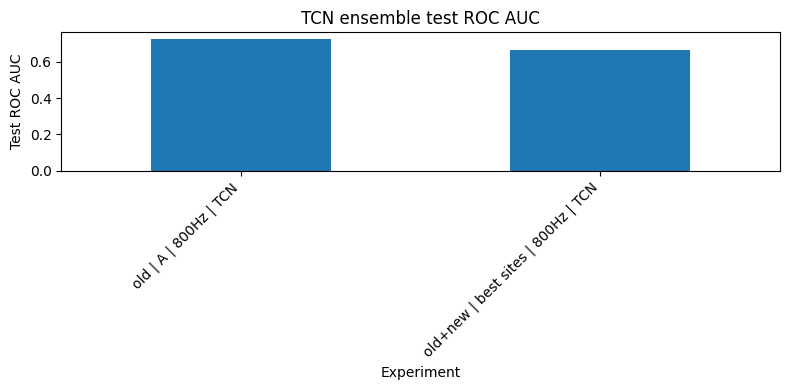

In [341]:
if not tcn_results_df.empty:
    ax = tcn_results_df.set_index("experiment")["test_roc_auc"].plot(
        kind="bar",
        figsize=(8, 4),
    )
    ax.set_title("TCN ensemble test ROC AUC")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Test ROC AUC")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [342]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## 9.8. Final threshold selection and confusion matrix

In [343]:
# =========================================================
# Definitive model: old | A | 800Hz | TCN
# =========================================================

In [344]:
FINAL_LABEL = "old | A | 800Hz | TCN"

# Reuse the same dataset already built for the TCN experiment
final_df = tcn_old_df.copy()

In [345]:
# Prepare the same patient-level split and tensors
prepared = _prepare_tcn_tensors(final_df)
if prepared[0] is None:
    raise ValueError("Could not prepare train/validation/test tensors.")

X_train, X_val, X_test, y_train, y_val, y_test = prepared

In [346]:
# Class weights
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(y_train), class_weight_values)
}

In [347]:
# Train one ensemble again and store validation/test probabilities
val_prob_dict = {}
test_prob_dict = {}
seed_rows = []

for seed in TCN_SEEDS:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = _build_tcn_model(
        input_length=X_train.shape[1],
        n_channels=X_train.shape[2],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=8,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
            verbose=0,
        ),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=TCN_MAX_EPOCHS,
        batch_size=TCN_BATCH_SIZE,
        verbose=0,
        class_weight=class_weight,
        callbacks=callbacks,
    )

    val_prob = model(X_val, training=False).numpy().ravel()
    test_prob = model(X_test, training=False).numpy().ravel()

    val_prob_dict[seed] = val_prob
    test_prob_dict[seed] = test_prob

    seed_rows.append({
        "seed": seed,
        "n_epochs_trained": int(len(history.history["loss"])),
        "val_roc_auc": float(roc_auc_score(y_val, val_prob)),
        "test_roc_auc": float(roc_auc_score(y_test, test_prob)),
    })

final_seed_df = pd.DataFrame(seed_rows).sort_values("test_roc_auc", ascending=False).reset_index(drop=True)

print("\nSeed-level summary for the definitive TCN model")
display(final_seed_df)


Seed-level summary for the definitive TCN model


,seed,n_epochs_trained,val_roc_auc,test_roc_auc
0,52,29,0.767857,0.792593
1,62,9,0.633929,0.681481
2,42,18,0.669643,0.666667


In [348]:
# Ensemble probabilities
ensemble_val_prob = np.mean(
    np.column_stack([val_prob_dict[seed] for seed in TCN_SEEDS]),
    axis=1,
)
ensemble_test_prob = np.mean(
    np.column_stack([test_prob_dict[seed] for seed in TCN_SEEDS]),
    axis=1,
)

In [349]:
# Select threshold on validation only
threshold_grid = np.arange(0.10, 0.91, 0.01)

threshold_rows = []
for thr in threshold_grid:
    val_pred = (ensemble_val_prob >= thr).astype(int)

    cm_val = confusion_matrix(y_val, val_pred, labels=[0, 1])
    tn, fp, fn, tp = cm_val.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    threshold_rows.append({
        "threshold": float(thr),
        "balanced_accuracy": float(balanced_accuracy_score(y_val, val_pred)),
        "sensitivity_recall": float(sensitivity),
        "specificity": float(specificity),
        "precision_ppv": float(precision_score(y_val, val_pred, zero_division=0)),
        "f1_score": float(f1_score(y_val, val_pred, zero_division=0)),
    })

threshold_search_df = pd.DataFrame(threshold_rows).sort_values(
    ["balanced_accuracy", "f1_score", "threshold"],
    ascending=[False, False, True],
).reset_index(drop=True)

best_threshold = float(threshold_search_df.loc[0, "threshold"])

print("\nBest threshold selected on validation")
display(threshold_search_df.head(10))



Best threshold selected on validation


,threshold,balanced_accuracy,sensitivity_recall,specificity,precision_ppv,f1_score
0,0.51,0.678571,0.50,0.857143,0.333333,0.400000
1,0.49,0.625000,0.75,0.500000,0.176471,0.285714
2,0.50,0.607143,0.50,0.714286,0.200000,0.285714
3,0.52,0.589286,0.25,0.928571,0.333333,0.285714
4,0.48,0.589286,1.00,0.178571,0.148148,0.258065
5,0.46,0.517857,1.00,0.035714,0.129032,0.228571
6,0.47,0.517857,1.00,0.035714,0.129032,0.228571
7,0.10,0.500000,1.00,0.000000,0.125000,0.222222
8,0.11,0.500000,1.00,0.000000,0.125000,0.222222
9,0.12,0.500000,1.00,0.000000,0.125000,0.222222


In [350]:
# Final test evaluation with the validation-selected threshold
y_test_pred = (ensemble_test_prob >= best_threshold).astype(int)

cm_test = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm_test.ravel()

final_test_metrics_df = pd.DataFrame([{
    "model": FINAL_LABEL,
    "threshold_selected_on_validation": best_threshold,
    "n_test": int(len(y_test)),
    "n_test_positive": int(y_test.sum()),
    "roc_auc_test": float(roc_auc_score(y_test, ensemble_test_prob)),
    "accuracy_test": float(accuracy_score(y_test, y_test_pred)),
    "balanced_accuracy_test": float(balanced_accuracy_score(y_test, y_test_pred)),
    "sensitivity_recall_test": float(recall_score(y_test, y_test_pred, zero_division=0)),
    "specificity_test": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
    "precision_ppv_test": float(precision_score(y_test, y_test_pred, zero_division=0)),
    "f1_score_test": float(f1_score(y_test, y_test_pred, zero_division=0)),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
}])

print("\nFinal test-set metrics for the definitive TCN model")
display(final_test_metrics_df)



Final test-set metrics for the definitive TCN model


,model,threshold_selected_on_validation,n_test,n_test_positive,roc_auc_test,accuracy_test,balanced_accuracy_test,sensitivity_recall_test,specificity_test,precision_ppv_test,f1_score_test,tn,fp,fn,tp
0,old | A | 800Hz | TCN,0.51,32,5,0.725926,0.75,0.525926,0.2,0.851852,0.2,0.2,23,4,4,1


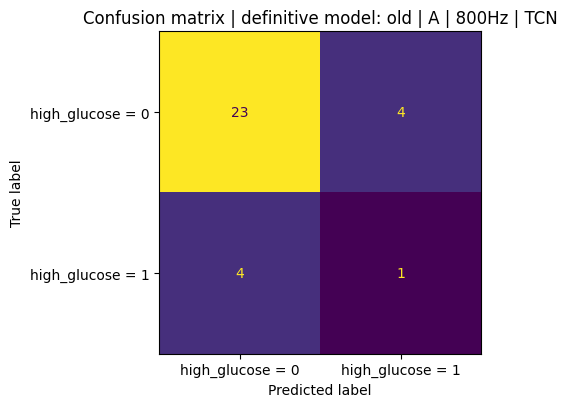

In [351]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["high_glucose = 0", "high_glucose = 1"],
)
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion matrix | definitive model: old | A | 800Hz | TCN")
plt.tight_layout()
plt.show()

## 9.9. Quick test: train on acquisition-level RAW SIGNAL evaluate on patient-level predictions


In [352]:
# Case: old | A | 800Hz

In [353]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

### 9.9.1. Build acquisition-level raw-signal table

In [354]:
def _build_acquisition_level_waveform_table(
    df,
    protocol_version="old",
    site_code="A",
    frequency_hz=800,
    target_col="high_glucose",
    target_length=2000,
):
    rows = []

    subset_df = df.loc[
        (df["protocol_version"] == protocol_version) &
        (df["site_code"] == site_code) &
        (df[target_col].notna())
    ].copy()

    for row in subset_df.itertuples(index=False):
        if not isinstance(row.freq_to_array, dict):
            continue
        if frequency_hz not in row.freq_to_array:
            continue

        waveform = _fix_length(
            row.freq_to_array[frequency_hz],
            target_length=target_length,
        )

        rows.append({
            "signal_record_id": row.signal_record_id,
            "global_patient_id": row.global_patient_id,
            "hospital_patient_id": row.hospital_patient_id,
            "timepoint": row.timepoint,
            "target": int(getattr(row, target_col)),
            "waveform": waveform,
        })

    return pd.DataFrame(rows)

In [355]:
acq_dl_df = _build_acquisition_level_waveform_table(
    stat_base_df,
    protocol_version="old",
    site_code="A",
    frequency_hz=800,
    target_col="high_glucose",
    target_length=DL_TARGET_LENGTH,
)

print("\nAcquisition-level dataset")
print("Rows:", len(acq_dl_df))
print("Patients:", acq_dl_df["global_patient_id"].nunique())
print("Positives:", int(acq_dl_df["target"].sum()))
display(acq_dl_df.head())


Acquisition-level dataset
Rows: 699
Patients: 157
Positives: 144


,signal_record_id,global_patient_id,hospital_patient_id,timepoint,target,waveform
0,sig_001581,1,540,POST,0,"[-0.016842978, -0.01766243, -0.018652538, -0.0..."
1,sig_001582,1,540,POST,0,"[0.23259692, 0.23023236, 0.24447802, 0.2527975..."
2,sig_001583,1,540,POST,0,"[-0.116369784, -0.11968656, -0.113998204, -0.1..."
3,sig_001590,2,533,POST,0,"[0.020864287, 0.021944044, 0.021841114, 0.0207..."
4,sig_001591,2,533,POST,0,"[0.00829233, 0.007887838, 0.007398596, 0.00792..."


### 9.9.2. Patient-level split

In [356]:
def _find_patient_split(df, group_col="global_patient_id", target_col="target"):
    for seed in range(42, 80):
        gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
        train_val_idx, test_idx = next(gss_test.split(df, groups=df[group_col]))

        train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)

        gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
        train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df[group_col]))

        train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
        val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

        if (
            train_df[target_col].nunique() == 2 and
            val_df[target_col].nunique() == 2 and
            test_df[target_col].nunique() == 2
        ):
            return train_df, val_df, test_df

    return None, None, None

In [357]:
train_df, val_df, test_df = _find_patient_split(acq_dl_df)

if train_df is None:
    raise ValueError("Could not find a valid patient-level split.")

print("\nSplit sizes")
print("Train acquisitions:", len(train_df))
print("Validation acquisitions:", len(val_df))
print("Test acquisitions:", len(test_df))
print("Test patients:", test_df["global_patient_id"].nunique())


Split sizes
Train acquisitions: 424
Validation acquisitions: 131
Test acquisitions: 144
Test patients: 32


### 9.9.3. Prepare tensors

In [358]:
X_train = np.stack(train_df["waveform"].to_numpy()).astype(np.float32)
X_val = np.stack(val_df["waveform"].to_numpy()).astype(np.float32)
X_test = np.stack(test_df["waveform"].to_numpy()).astype(np.float32)

y_train = train_df["target"].astype(int).to_numpy()
y_val = val_df["target"].astype(int).to_numpy()
y_test = test_df["target"].astype(int).to_numpy()

train_mean = float(X_train.mean())
train_std = float(X_train.std()) if float(X_train.std()) > 0 else 1.0

X_train = ((X_train - train_mean) / train_std)[..., np.newaxis]
X_val = ((X_val - train_mean) / train_std)[..., np.newaxis]
X_test = ((X_test - train_mean) / train_std)[..., np.newaxis]

### 9.9.4. Small raw-signal model

In [359]:
def _build_quick_raw_cnn(input_length):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.Conv1D(16, 9, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(32, 7, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(64, 5, padding="same", activation="relu"),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")],
    )
    return model



In [360]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(y_train), class_weight_values)
}

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = _build_quick_raw_cnn(X_train.shape[1])

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=8,
        restore_best_weights=True,
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=0,
    class_weight=class_weight,
    callbacks=callbacks,
)

### 9.9.5. Predict on test acquisitions

In [361]:
test_df = test_df.copy()
test_df["pred_prob_acq"] = model(X_test, training=False).numpy().ravel()

# Acquisition-level metric
acq_roc_auc = roc_auc_score(test_df["target"], test_df["pred_prob_acq"])


### 9.9.6. Aggregate to patient level for final evaluation

In [362]:
patient_pred_df = (
    test_df.groupby("global_patient_id", as_index=False)
    .agg(
        target=("target", "first"),
        pred_prob_patient=("pred_prob_acq", "mean"),
        n_acquisitions=("signal_record_id", "nunique"),
    )
)

patient_pred_df["pred_label_patient"] = (
    patient_pred_df["pred_prob_patient"] >= 0.5
).astype(int)

patient_metrics_df = pd.DataFrame([{
    "n_test_patients": int(len(patient_pred_df)),
    "n_test_positive_patients": int(patient_pred_df["target"].sum()),
    "acquisition_level_roc_auc": float(acq_roc_auc),
    "patient_level_roc_auc": float(roc_auc_score(patient_pred_df["target"], patient_pred_df["pred_prob_patient"])),
    "patient_level_balanced_accuracy": float(
        balanced_accuracy_score(patient_pred_df["target"], patient_pred_df["pred_label_patient"])
    ),
}])

print("\nPatient-level aggregated predictions")
display(patient_pred_df.head(20))

print("\nMetrics")
display(patient_metrics_df)


Patient-level aggregated predictions


,global_patient_id,target,pred_prob_patient,n_acquisitions,pred_label_patient
0,10,0,0.493747,3,0
1,13,0,0.496854,3,0
2,16,0,0.495178,3,0
3,19,0,0.496661,3,0
4,20,0,0.494557,3,0
5,25,0,0.494106,5,0
6,30,1,0.501454,3,1
7,31,0,0.502884,3,1
8,32,0,0.501014,3,1
9,46,0,0.505219,4,1



Metrics


,n_test_patients,n_test_positive_patients,acquisition_level_roc_auc,patient_level_roc_auc,patient_level_balanced_accuracy
0,32,5,0.655866,0.637037,0.596296
